## Observation Notes
#### Class imbalance 
1. GALAXY    0.653818
2. QSO       0.202899
3. STAR      0.143283

In [17]:
# Imports
import pandas as pd
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Configurations
ROOT_PATH = "playground-series-s6e6"
BENCHMARK = 0.97
SEED = 42
N_FOLDS = 5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cpu


In [6]:
train_df_org = pd.read_csv(os.path.join(ROOT_PATH, 'train.csv'))
test_df_org = pd.read_csv(os.path.join(ROOT_PATH, 'test.csv'))
sub_org = pd.read_csv(os.path.join(ROOT_PATH, 'sample_submission.csv'))

print(f"Shap of train : {train_df_org.shape} | test : {test_df_org.shape} | submissions : {sub_org.shape}")
print(f"Target distribution train : \n{train_df_org['class'].value_counts(normalize=True)}")

Shap of train : (577347, 12) | test : (247435, 11) | submissions : (247435, 2)
Target distribution train : 
class
GALAXY    0.653818
QSO       0.202899
STAR      0.143283
Name: proportion, dtype: float64


## Correlation (Train | Test)
- Show correlation plot
- Decide Feature Engineering

Numerical columns : ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
Categorical columns : ['spectral_type', 'galaxy_population']


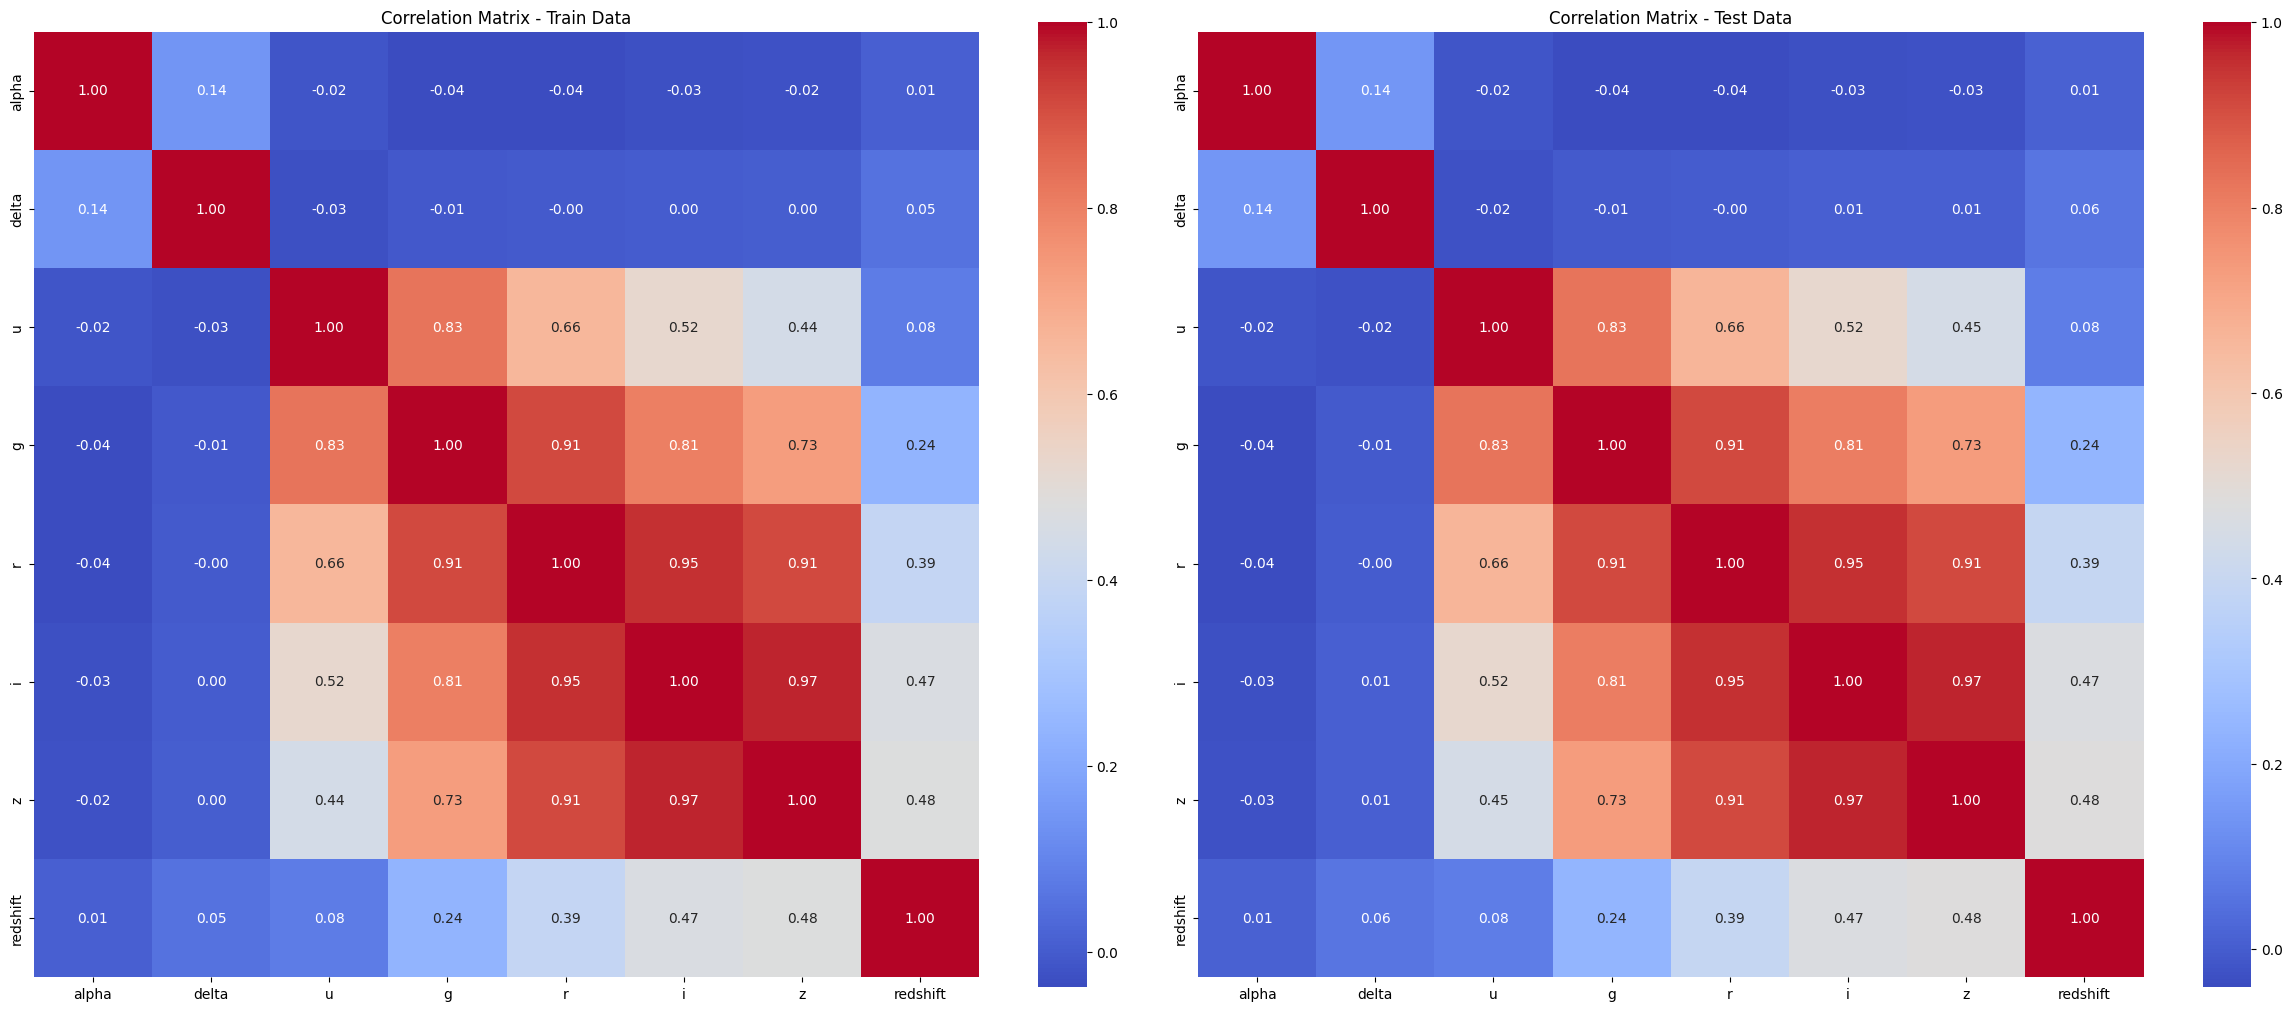

In [27]:
train_df = train_df_org.copy()
test_df = test_df_org.copy()

n_cols = train_df.drop(columns=['id', 'class'], axis='columns').select_dtypes(exclude='object').columns.to_list()
c_cols = train_df.drop(columns=['id', 'class'], axis='columns').select_dtypes(include='object').columns.to_list()
print(f"Numerical columns : {n_cols}")
print(f"Categorical columns : {c_cols}")

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(train_df[n_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=axes[0])
axes[0].set_title("Correlation Matrix - Train Data")

sns.heatmap(test_df[n_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=axes[1])
axes[1].set_title("Correlation Matrix - Test Data")

plt.tight_layout()
plt.show()

Updated Categorical columns : ['spectral_type', 'galaxy_population', 'spectral_type_&_galaxy_population']


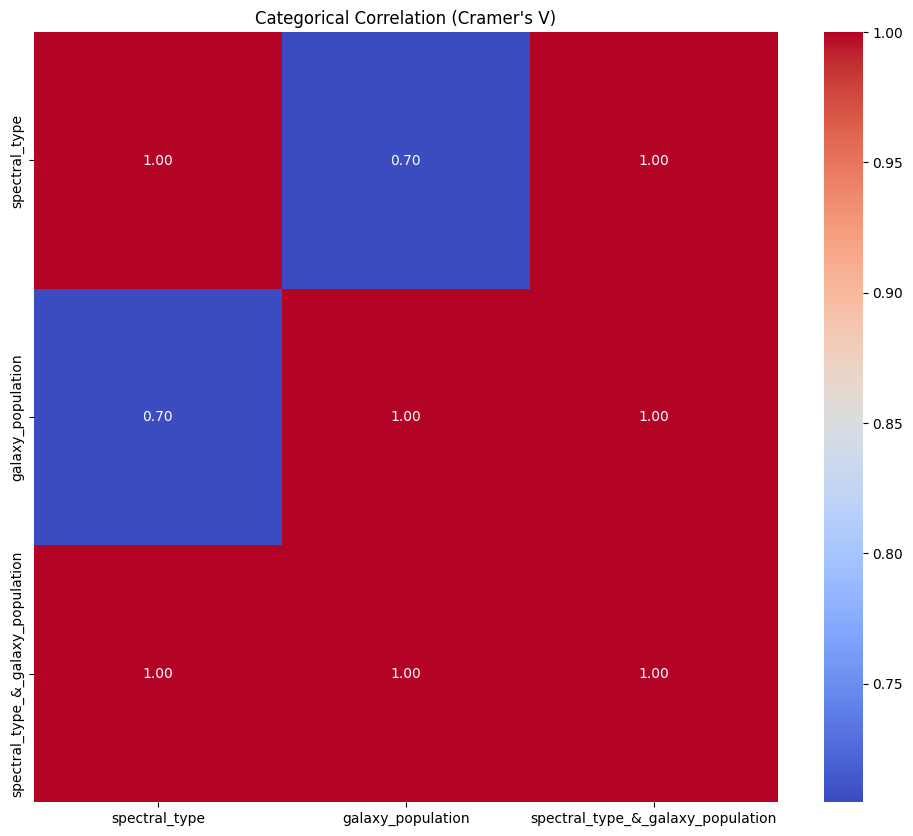

In [28]:
train_df['_&_'.join(c_cols)] = train_df[c_cols].apply(lambda x: '_&_'.join(x.astype(str)), axis=1)
test_df['_&_'.join(c_cols)] = test_df[c_cols].apply(lambda x: '_&_'.join(x.astype(str)), axis=1)
c_cols.append('_&_'.join(c_cols))
print(f"Updated Categorical columns : {c_cols}")

def cramers_v(x, y):
    cm = pd.crosstab(x, y)
    chi2 = chi2_contingency(cm)[0]
    n = cm.sum().sum()
    r, k = cm.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

cat_corr = pd.DataFrame(index=c_cols, columns=c_cols)

for col1 in c_cols:
    for col2 in c_cols:
        cat_corr.loc[col1, col2] = cramers_v(train_df[col1], train_df[col2])

cat_corr = cat_corr.astype(float)

plt.figure(figsize=(12, 10))
sns.heatmap(cat_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Categorical Correlation (Cramer's V)")
plt.show()